```text
Ablation_Cross_Validation
│
├── KFold loop
│   ├── Baseline model (todas as features)
│   │     └── calcular métricas
│   ├── Para cada feature:
│   │     ├── remover feature
│   │     ├── treinar modelo
│   │     └── calcular métricas
│   │
│   └── guardar resultados por fold
│
└── devolver DataFrame completo
```

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)
from sklearn.linear_model import LinearRegression

### Helper Function: Calculate the Metrics

In [2]:
def calculate_metrics(y_true, y_pred, n_features):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # Adjusted R²
    n = len(y_true)
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)

    # MAPE (proteger divisão por zero)
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-8, None))) * 100

    return {
        "r2": r2,
        "adjusted_r2": adjusted_r2,
        "rmse": rmse,
        "mae": mae,
        "mse": mse,
        "mape": mape
    }


### Base Main Function - Ablation Cross Validation

In [3]:
'''def ablation_cross_validation(
    X,
    y,
    model,
    cv_folds=5,
    features_to_test=None,
    random_state=42,
    save_csv_path=None
):
    """
    Perform ablation study with k-fold cross-validation.

    Returns a DataFrame with per-fold metrics for:
    - Full model
    - One-feature-removed models
    """

    if features_to_test is None:
        features_to_test = X.columns.tolist()

    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    results = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # ==========================
        # 🔹 BASELINE MODEL
        # ==========================
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        base_metrics = calculate_metrics(
            y_test,
            y_pred,
            n_features=X_train.shape[1]
        )

        results.append({
            "model_variant": "Baseline",
            "features_removed": "None",
            "fold": fold,
            **base_metrics
        })

        baseline_r2 = base_metrics["r2"]
        baseline_rmse = base_metrics["rmse"]

        # ==========================
        # 🔹 ABLATION: ONE FEATURE AT A TIME
        # ==========================
        for feature in features_to_test:
            X_train_abl = X_train.drop(columns=[feature])
            X_test_abl = X_test.drop(columns=[feature])

            model.fit(X_train_abl, y_train)
            y_pred_abl = model.predict(X_test_abl)

            abl_metrics = calculate_metrics(
                y_test,
                y_pred_abl,
                n_features=X_train_abl.shape[1]
            )

            results.append({
                "model_variant": f"- {feature}",
                "features_removed": feature,
                "fold": fold,
                **abl_metrics,
                "delta_r2": abl_metrics["r2"] - baseline_r2,
                "delta_rmse": abl_metrics["rmse"] - baseline_rmse
            })

    results_df = pd.DataFrame(results)

    if save_csv_path:
        results_df.to_csv(save_csv_path, index=False)

    return results_df'''


'def ablation_cross_validation(\n    X,\n    y,\n    model,\n    cv_folds=5,\n    features_to_test=None,\n    random_state=42,\n    save_csv_path=None\n):\n    """\n    Perform ablation study with k-fold cross-validation.\n\n    Returns a DataFrame with per-fold metrics for:\n    - Full model\n    - One-feature-removed models\n    """\n\n    if features_to_test is None:\n        features_to_test = X.columns.tolist()\n\n    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=random_state)\n\n    results = []\n\n    for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):\n        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]\n        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]\n\n        # ==========================\n        # 🔹 BASELINE MODEL\n        # ==========================\n        model.fit(X_train, y_train)\n        y_pred = model.predict(X_test)\n\n        base_metrics = calculate_metrics(\n            y_test,\n            y_pred,\n          

# Ablation Study

## What is an Ablation Study?

An **ablation study** is an experimental technique used to understand the **contribution of each feature** to a machine learning model.  
The idea is simple: start with a **baseline model** that uses all available features, and then **systematically remove one feature at a time** to observe how model performance changes.

If removing a feature causes performance to degrade significantly, that feature is considered **important**.  
If performance stays the same or improves, the feature may be **irrelevant or even harmful**.

---

## Objective of This Ablation Study

The goal of this ablation study is to:
- Quantify the **impact of each feature** on a linear regression model
- Validate the results of the feature selection step
- Identify features that contribute positively, marginally, or negatively to model performance

---

## Methodology

1. **Baseline Model**
   - A linear regression model is trained using **all selected features**
   - Performance metrics are computed using **k-fold cross-validation**

2. **Feature Removal (One at a Time)**
   - For each feature, a new model is trained **excluding that feature**
   - The same cross-validation procedure is applied

3. **Performance Comparison**
   - The performance of each ablated model is compared against the baseline
   - Differences in metrics such as **R²** and **RMSE** are computed

---

## Cross-Validation Setup

- **Model:** Linear Regression  
- **Validation Strategy:** K-Fold Cross-Validation  
- **Number of Folds:** 5  
- **Evaluation performed independently on each fold** to ensure robustness and avoid data leakage

---

## Evaluation Metrics

The following metrics are computed for each fold and model variant:

- **R² (Coefficient of Determination)**  
  Measures how much variance in the target variable is explained by the model

- **Adjusted R²**  
  Penalizes unnecessary features and accounts for model complexity

- **RMSE (Root Mean Squared Error)**  
  Measures average prediction error magnitude (sensitive to large errors)

- **MAE (Mean Absolute Error)**  
  Measures average absolute prediction error

- **MSE (Mean Squared Error)**  
  Squared version of RMSE, useful for optimization comparison

- **MAPE (Mean Absolute Percentage Error)**  
  Expresses error as a percentage of the true values

---

## Result Table Structure

Each experiment produces a table with the following structure:

| Column Name | Description |
|------------|------------|
| `model_variant` | Name of the model (Baseline or feature removed) |
| `features_removed` | Feature removed from the model |
| `fold` | Cross-validation fold number |
| `r2` | R² score |
| `adjusted_r2` | Adjusted R² |
| `rmse` | Root Mean Squared Error |
| `mae` | Mean Absolute Error |
| `mse` | Mean Squared Error |
| `mape` | Mean Absolute Percentage Error |
| `delta_r2` | Difference in R² relative to baseline |
| `delta_rmse` | Difference in RMSE relative to baseline |

---

## Interpretation of Results

- **Large drop in R² and increase in RMSE**  
  → The removed feature is **highly important**

- **Small performance change**  
  → The feature has **moderate or low impact**

- **Performance improvement after removal**  
  → The feature likely introduces **noise or redundancy**

---

## Key Findings

- Critical features cause a **strong degradation** in performance when removed
- Some features show **minimal impact**, suggesting redundancy
- A few features may **improve performance when removed**, indicating overfitting or noise

This confirms that the model relies on a **small subset of highly informative features**, validating the feature selection strategy.

---

## Why Ablation Studies Matter

Ablation studies:
- Improve **model interpretability**
- Provide **empirical justification** for feature selection
- Help reduce model complexity without sacrificing performance
- Strengthen the credibility of the final model

---

## Conclusion

The ablation study demonstrates how each feature contributes to model performance.  
By systematically removing features and analyzing performance changes, we gain a **clear, data-driven understanding** of feature importance and model robustness.



PROGRESSIVE ABLATION STUDY DEMONSTRATION
Dataset: 300 samples, 12 features
Informative features: 6 (synthetic)
Model: Random Forest Regressor
Primary metric: RMSE (lower is better)
Additional metrics: R², MSE, MAE, MAPE
Cross-validation: 5 folds

🏁 STARTING PROGRESSIVE ABLATION ANALYSIS
   This will show each combination as it's being tested...

STEP 1: INITIAL ABLATION STUDY
Testing baseline with all 12 features...
Primary metric: RMSE

  Fold 1/5
  Training with ALL 12 features...
  Testing removal of each feature...

  Fold 2/5
  Training with ALL 12 features...
  Testing removal of each feature...

  Fold 3/5
  Training with ALL 12 features...
  Testing removal of each feature...

  Fold 4/5
  Training with ALL 12 features...
  Testing removal of each feature...

  Fold 5/5
  Training with ALL 12 features...
  Testing removal of each feature...

✓ Baseline with all 12 features:
  Primary metric (RMSE): 50.6668 ± 7.7760

  All metrics:
    R2    : 0.8174 ± 0.0405
    MSE   : 2615.49

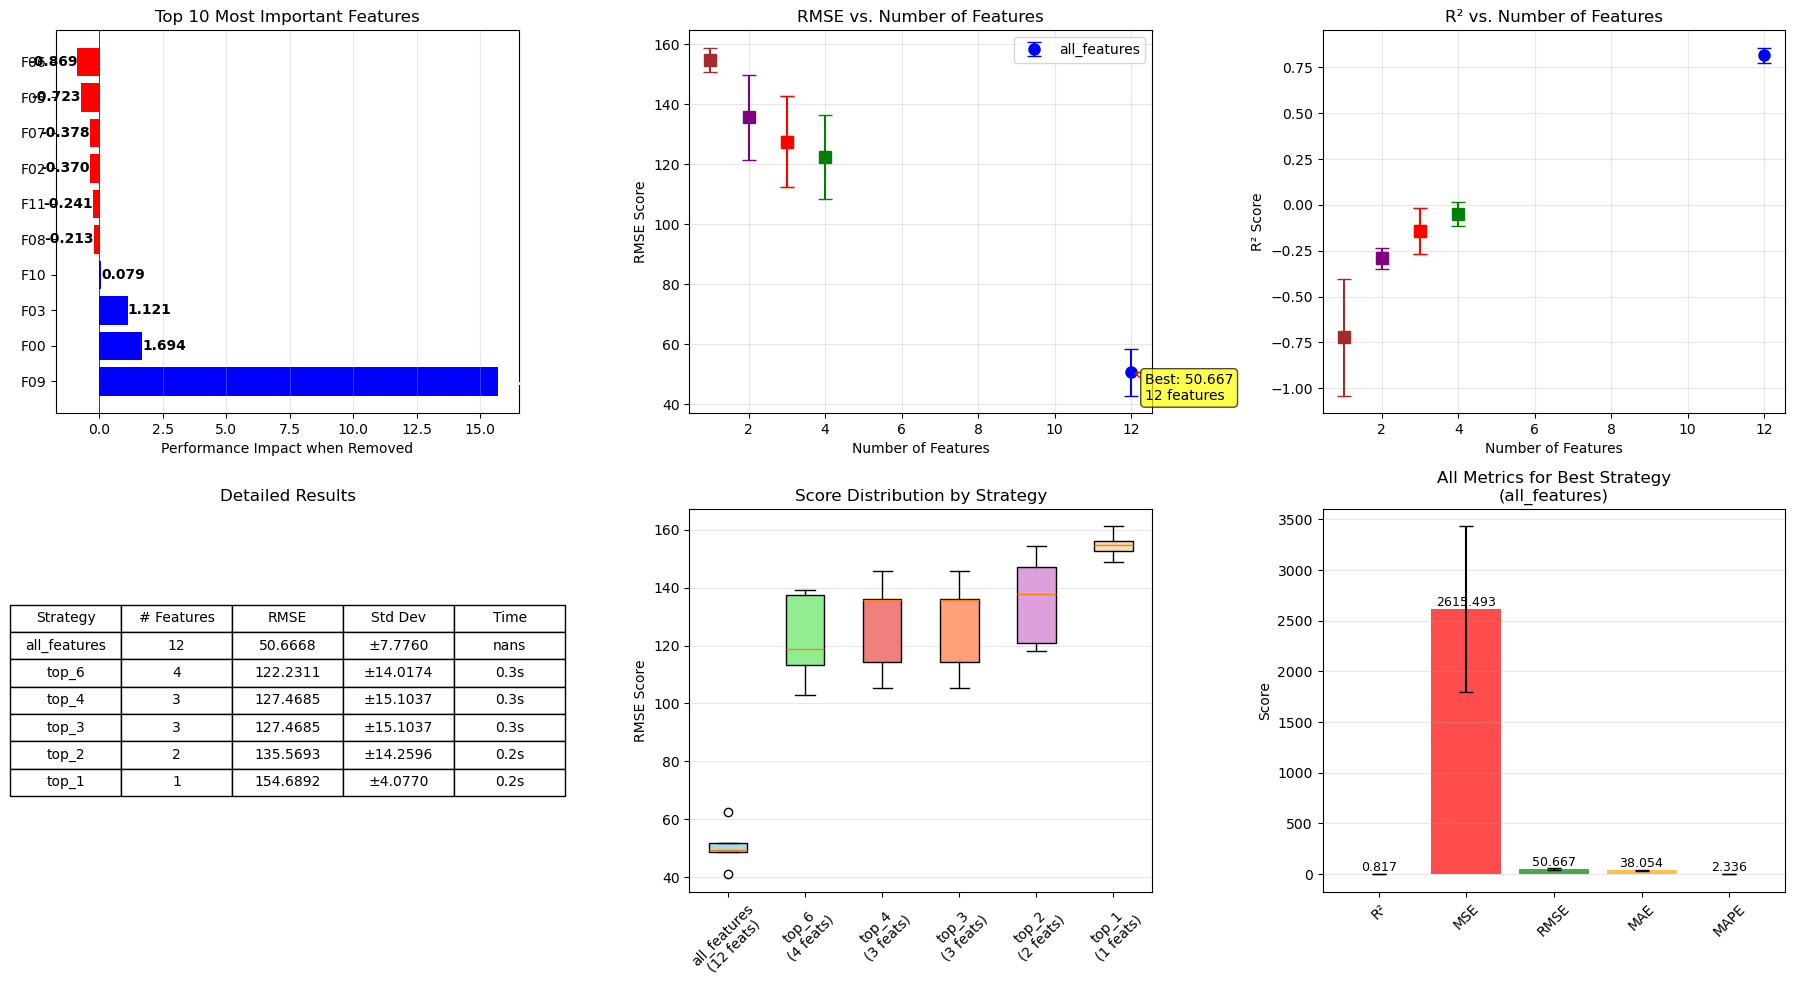


PROGRESSIVE ABLATION STUDY - FINAL SUMMARY

🎯 OPTIMAL FEATURE SUBSET FOUND:
   ┌──────────────────────────────────────────────────────┐
   │ Strategy: all_features                        │
   │ Features: 12 features        │
   │ Primary metric (RMSE): 50.6668 ± 7.7760 │
   │ Time: nans                               │
   └──────────────────────────────────────────────────────┘
   Feature list: ['F00', 'F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11']

📊 COMPREHENSIVE METRICS for optimal subset:
   R2    : 0.8174 ± 0.0405
   MSE   : 2615.4930 ± 814.8526
   RMSE  : 50.6668 ± 7.7760
   MAE   : 38.0544 ± 4.7110
   MAPE  : 2.3359 ± 3.5510

📈 COMPARISON TO BASELINE (All Features):
   Baseline (12 features): 50.6668
   Optimal (12 features): 50.6668
   Improvement: ↑ 0.0000 (HIGHER)
   Features reduced by: 0 (0.0%)

🔍 FEATURE IMPORTANCE RANKING (Top 8):
   Rank Feature      Importance   Impact    
   ──── ──────────── ──────────── ──────────
      1 F06            

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from itertools import combinations
import warnings
import time
warnings.filterwarnings('ignore')

class ProgressiveAblationSelector:
    """
    Progressive ablation study testing decreasing feature subsets:
    All features → Top 6 → Top 4 → Top 3 → Top 2 → Top 1
    
    Supports multiple metrics: R², RMSE, MAE, MSE, MAPE
    """
    
    def __init__(self, model, metric='r2', cv_folds=5, random_state=42, verbose=True):
        """
        Args:
            model: Sklearn-compatible model
            metric: Evaluation metric ('r2', 'rmse', 'mse', 'mae', 'mape')
            cv_folds: Number of cross-validation folds
            random_state: Random seed for reproducibility
            verbose: Print detailed progress
        """
        self.model = model
        self.metric = metric.lower()
        self.cv_folds = cv_folds
        self.random_state = random_state
        self.verbose = verbose
        self.results = {}
        self.feature_importance_df = None
        self.progressive_results = []
        
    def _calculate_metric(self, y_true, y_pred):
        """Calculate the specified evaluation metric."""
        if self.metric == 'r2':
            return r2_score(y_true, y_pred)
        elif self.metric == 'mse':
            return mean_squared_error(y_true, y_pred)
        elif self.metric == 'rmse':
            return np.sqrt(mean_squared_error(y_true, y_pred))
        elif self.metric == 'mae':
            return mean_absolute_error(y_true, y_pred)
        elif self.metric == 'mape':
            # MAPE can have division by zero, so we handle it carefully
            try:
                return mean_absolute_percentage_error(y_true, y_pred)
            except:
                # Handle cases where y_true contains zeros
                y_true_nonzero = np.where(y_true == 0, np.finfo(float).eps, y_true)
                return np.mean(np.abs((y_true - y_pred) / y_true_nonzero))
        else:
            raise ValueError(f"Unsupported metric: {self.metric}. Supported: 'r2', 'rmse', 'mse', 'mae', 'mape'")
    
    def _calculate_all_metrics(self, y_true, y_pred):
        """Calculate all metrics for comprehensive evaluation."""
        metrics = {}
        
        # R²
        try:
            metrics['r2'] = r2_score(y_true, y_pred)
        except:
            metrics['r2'] = np.nan
        
        # MSE
        try:
            metrics['mse'] = mean_squared_error(y_true, y_pred)
        except:
            metrics['mse'] = np.nan
        
        # RMSE
        try:
            metrics['rmse'] = np.sqrt(mean_squared_error(y_true, y_pred))
        except:
            metrics['rmse'] = np.nan
        
        # MAE
        try:
            metrics['mae'] = mean_absolute_error(y_true, y_pred)
        except:
            metrics['mae'] = np.nan
        
        # MAPE
        try:
            metrics['mape'] = mean_absolute_percentage_error(y_true, y_pred)
        except:
            try:
                y_true_nonzero = np.where(y_true == 0, np.finfo(float).eps, y_true)
                metrics['mape'] = np.mean(np.abs((y_true - y_pred) / y_true_nonzero))
            except:
                metrics['mape'] = np.nan
        
        return metrics
    
    def perform_initial_ablation(self, X, y, feature_names=None):
        """
        Step 1: Initial ablation study with all features.
        Ranks features from most important to least important.
        """
        if feature_names is None:
            feature_names = [f'Feature_{i}' for i in range(X.shape[1])]
        
        n_features = len(feature_names)
        kf = KFold(n_splits=self.cv_folds, shuffle=True, random_state=self.random_state)
        
        # Store results for each feature removal
        fold_results = {feature: [] for feature in feature_names}
        baseline_metrics_all_folds = []
        
        print("\n" + "="*70)
        print("STEP 1: INITIAL ABLATION STUDY")
        print("="*70)
        print(f"Testing baseline with all {n_features} features...")
        print(f"Primary metric: {self.metric.upper()}")
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
            if self.verbose:
                print(f"\n  Fold {fold}/{self.cv_folds}")
                print(f"  Training with ALL {n_features} features...")
            
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]
            
            # Baseline with all features
            model_base = clone(self.model)
            model_base.fit(X_train, y_train)
            y_pred_base = model_base.predict(X_val)
            
            # Calculate primary metric
            baseline_score = self._calculate_metric(y_val, y_pred_base)
            
            # Calculate all metrics for comprehensive analysis
            baseline_metrics = self._calculate_all_metrics(y_val, y_pred_base)
            baseline_metrics['fold'] = fold
            baseline_metrics_all_folds.append(baseline_metrics)
            
            if self.verbose:
                print(f"  Testing removal of each feature...")
            
            # Test removing each feature
            for i, feature in enumerate(feature_names):
                # Create dataset without this feature
                X_train_ablated = np.delete(X_train, i, axis=1)
                X_val_ablated = np.delete(X_val, i, axis=1)
                
                # Train and evaluate
                model_ablated = clone(self.model)
                model_ablated.fit(X_train_ablated, y_train)
                y_pred_ablated = model_ablated.predict(X_val_ablated)
                ablated_score = self._calculate_metric(y_val, y_pred_ablated)
                
                # Calculate performance drop (importance)
                # For error metrics (lower is better), negative drop means improvement
                # For R² (higher is better), positive drop means feature is important
                if self.metric in ['r2']:
                    performance_drop = baseline_score - ablated_score  # Positive = important
                else:  # mse, rmse, mae, mape
                    performance_drop = ablated_score - baseline_score  # Positive = harmful
                
                fold_results[feature].append(performance_drop)
        
        # Average results across folds
        feature_importance = {
            feature: np.mean(scores) for feature, scores in fold_results.items()
        }
        
        # Create DataFrame sorted by importance
        # For R²: higher positive = more important
        # For error metrics: higher negative = more important (removing increases error)
        self.feature_importance_df = pd.DataFrame({
            'feature': list(feature_importance.keys()),
            'importance': list(feature_importance.values()),
            'abs_importance': [abs(v) for v in feature_importance.values()]
        })
        
        # Sort based on metric type
        if self.metric == 'r2':
            # For R², sort descending (positive values are good)
            self.feature_importance_df = self.feature_importance_df.sort_values('importance', ascending=False)
        else:
            # For error metrics, sort ascending (negative values mean removing hurts performance)
            self.feature_importance_df = self.feature_importance_df.sort_values('importance')
        
        self.feature_importance_df = self.feature_importance_df.reset_index(drop=True)
        
        # Calculate average baseline metrics
        baseline_metrics_df = pd.DataFrame(baseline_metrics_all_folds)
        baseline_mean_metrics = baseline_metrics_df.mean()
        baseline_std_metrics = baseline_metrics_df.std()
        
        print(f"\n✓ Baseline with all {n_features} features:")
        print(f"  Primary metric ({self.metric.upper()}): {baseline_mean_metrics[self.metric]:.4f} ± {baseline_std_metrics[self.metric]:.4f}")
        print(f"\n  All metrics:")
        for metric in ['r2', 'mse', 'rmse', 'mae', 'mape']:
            if metric in baseline_mean_metrics:
                print(f"    {metric.upper():6s}: {baseline_mean_metrics[metric]:.4f} ± {baseline_std_metrics[metric]:.4f}")
        
        # Store baseline result
        self.progressive_results.append({
            'n_features': n_features,
            'features': feature_names,
            'strategy': 'all_features',
            'primary_metric': self.metric,
            'mean_score': baseline_mean_metrics[self.metric],
            'std_score': baseline_std_metrics[self.metric],
            'all_metrics': baseline_mean_metrics.to_dict(),
            'all_metrics_std': baseline_std_metrics.to_dict(),
            'fold_scores': baseline_metrics_df[self.metric].tolist()
        })
        
        print(f"\n✓ Feature importance ranking completed!")
        return self.feature_importance_df
    
    def progressive_ablation_analysis(self, X, y, feature_names=None):
        """
        Step 2: Progressive ablation study with decreasing feature sets:
        All → Top 6 → Top 4 → Top 3 → Top 2 → Top 1
        """
        if feature_names is None:
            feature_names = [f'Feature_{i}' for i in range(X.shape[1])]
        
        if self.feature_importance_df is None:
            self.perform_initial_ablation(X, y, feature_names)
        
        n_features = len(feature_names)
        
        # Define the progressive sequence
        if n_features >= 6:
            top_n_list = [6, 4, 3, 2, 1]
        elif n_features >= 4:
            top_n_list = [4, 3, 2, 1]
        elif n_features >= 3:
            top_n_list = [3, 2, 1]
        elif n_features >= 2:
            top_n_list = [2, 1]
        else:
            top_n_list = [1]
        
        print("\n" + "="*70)
        print("STEP 2: PROGRESSIVE ABLATION ANALYSIS")
        print("="*70)
        print(f"Testing sequence: All → {top_n_list}")
        print(f"For each step, testing ALL combinations within the top features")
        print(f"Primary metric: {self.metric.upper()}")
        
        kf = KFold(n_splits=self.cv_folds, shuffle=True, random_state=self.random_state)
        
        for top_n in top_n_list:
            # Get top N features based on initial ranking
            top_features = self.feature_importance_df.head(top_n)['feature'].tolist()
            feature_indices = [feature_names.index(f) for f in top_features]
            
            print(f"\n" + "-"*60)
            print(f"🔍 TESTING TOP {top_n} FEATURES:")
            print(f"   Features: {top_features}")
            print("-"*60)
            
            # Test different combinations within this top-N group
            if self.metric == 'r2':
                best_combo_score = -np.inf  # Higher is better
            else:
                best_combo_score = np.inf   # Lower is better
            
            best_combo = None
            
            total_combinations = sum(1 for r in range(1, top_n + 1) for _ in combinations(feature_indices, r))
            combo_count = 0
            
            # Test all subsets of these top N features
            for r in range(1, top_n + 1):
                for combo_indices in combinations(feature_indices, r):
                    combo_count += 1
                    combo_features = [feature_names[i] for i in combo_indices]
                    
                    if self.verbose:
                        print(f"\n  Testing combination {combo_count}/{total_combinations}:")
                        print(f"    Features ({len(combo_features)}): {combo_features}")
                    
                    X_subset = X[:, list(combo_indices)]
                    
                    # Cross-validate
                    start_time = time.time()
                    primary_scores = []
                    all_metrics_list = []
                    
                    for fold, (train_idx, val_idx) in enumerate(kf.split(X_subset), 1):
                        X_train, X_val = X_subset[train_idx], X_subset[val_idx]
                        y_train, y_val = y[train_idx], y[val_idx]
                        
                        model = clone(self.model)
                        model.fit(X_train, y_train)
                        y_pred = model.predict(X_val)
                        
                        # Calculate primary metric
                        primary_score = self._calculate_metric(y_val, y_pred)
                        primary_scores.append(primary_score)
                        
                        # Calculate all metrics
                        all_metrics = self._calculate_all_metrics(y_val, y_pred)
                        all_metrics['fold'] = fold
                        all_metrics_list.append(all_metrics)
                    
                    mean_primary_score = np.mean(primary_scores)
                    std_primary_score = np.std(primary_scores)
                    
                    # Calculate mean of all metrics
                    all_metrics_df = pd.DataFrame(all_metrics_list)
                    mean_all_metrics = all_metrics_df.mean().to_dict()
                    std_all_metrics = all_metrics_df.std().to_dict()
                    
                    elapsed = time.time() - start_time
                    
                    if self.verbose:
                        print(f"    {self.metric.upper()}: {mean_primary_score:.4f} ± {std_primary_score:.4f}")
                        print(f"    Time: {elapsed:.2f}s")
                    
                    # Check if this is the best combination
                    if self.metric == 'r2':
                        is_better = mean_primary_score > best_combo_score
                    else:
                        is_better = mean_primary_score < best_combo_score
                    
                    if is_better:
                        best_combo_score = mean_primary_score
                        best_combo = {
                            'indices': combo_indices,
                            'features': combo_features,
                            'primary_scores': primary_scores,
                            'mean_primary_score': mean_primary_score,
                            'std_primary_score': std_primary_score,
                            'all_metrics': mean_all_metrics,
                            'all_metrics_std': std_all_metrics,
                            'elapsed_time': elapsed
                        }
                        
                        if self.verbose:
                            print(f"    🎯 NEW BEST for top {top_n}!")
            
            if best_combo:
                self.progressive_results.append({
                    'n_features': len(best_combo['indices']),
                    'features': best_combo['features'],
                    'strategy': f'top_{top_n}_best_combo',
                    'primary_metric': self.metric,
                    'mean_score': best_combo['mean_primary_score'],
                    'std_score': best_combo['std_primary_score'],
                    'all_metrics': best_combo['all_metrics'],
                    'all_metrics_std': best_combo['all_metrics_std'],
                    'fold_scores': best_combo['primary_scores'],
                    'elapsed_time': best_combo['elapsed_time']
                })
                
                print(f"\n✓ BEST COMBINATION for top {top_n}:")
                print(f"  Features: {len(best_combo['features'])}")
                print(f"  {self.metric.upper()}: {best_combo['mean_primary_score']:.4f} ± {best_combo['std_primary_score']:.4f}")
                print(f"  Features: {best_combo['features']}")
                print(f"  Time: {best_combo['elapsed_time']:.2f}s")
                
                # Show all metrics for the best combination
                if self.verbose:
                    print(f"  All metrics:")
                    for metric_name in ['r2', 'mse', 'rmse', 'mae', 'mape']:
                        if metric_name in best_combo['all_metrics']:
                            metric_val = best_combo['all_metrics'][metric_name]
                            metric_std = best_combo['all_metrics_std'].get(metric_name, 0)
                            print(f"    {metric_name.upper():6s}: {metric_val:.4f} ± {metric_std:.4f}")
        
        # Convert to DataFrame and sort appropriately
        progressive_df = pd.DataFrame(self.progressive_results)
        
        # Sort by score based on metric type
        if self.metric == 'r2':
            progressive_df = progressive_df.sort_values('mean_score', ascending=False)
        else:
            progressive_df = progressive_df.sort_values('mean_score')
        
        print("\n" + "="*70)
        print("✓ PROGRESSIVE ABLATION COMPLETED!")
        print("="*70)
        
        return progressive_df
    
    def plot_results(self):
        """Plot progressive ablation results."""
        if not self.progressive_results:
            print("No progressive results to plot. Run progressive_ablation_analysis first.")
            return
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        
        # Plot 1: Feature importance ranking
        if self.feature_importance_df is not None:
            ax1 = axes[0, 0]
            importance_df = self.feature_importance_df.copy()
            
            # Show top 10 or all if less than 10
            n_to_show = min(10, len(importance_df))
            top_features = importance_df.head(n_to_show)
            
            # Color based on importance direction
            if self.metric == 'r2':
                colors = ['red' if x > 0 else 'blue' for x in top_features['importance']]
            else:
                colors = ['red' if x < 0 else 'blue' for x in top_features['importance']]
            
            bars = ax1.barh(range(n_to_show), top_features['importance'], color=colors)
            ax1.set_yticks(range(n_to_show))
            ax1.set_yticklabels(top_features['feature'])
            ax1.invert_yaxis()
            ax1.set_xlabel('Performance Impact when Removed')
            ax1.set_title(f'Top {n_to_show} Most Important Features')
            ax1.grid(True, alpha=0.3, axis='x')
            ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
            
            # Add value labels
            for i, (bar, val) in enumerate(zip(bars, top_features['importance'])):
                ax1.text(val, i, f'{val:.3f}', 
                        va='center', ha='left' if val >= 0 else 'right',
                        color='white' if abs(val) > np.abs(top_features['importance'].max() * 0.5) else 'black',
                        fontweight='bold')
        
        # Plot 2: Performance vs Number of Features (primary metric)
        ax2 = axes[0, 1]
        progressive_df = pd.DataFrame(self.progressive_results)
        
        # For display, sort by n_features
        display_df = progressive_df.copy()
        display_df = display_df.sort_values('n_features')
        
        # Group by strategy type for coloring
        colors = {'all_features': 'blue', 'top_6_best_combo': 'green', 
                 'top_4_best_combo': 'orange', 'top_3_best_combo': 'red',
                 'top_2_best_combo': 'purple', 'top_1_best_combo': 'brown'}
        
        for idx, row in display_df.iterrows():
            color = colors.get(row['strategy'], 'gray')
            marker = 'o' if 'all' in row['strategy'] else 's'
            ax2.errorbar(row['n_features'], row['mean_score'], 
                        yerr=row['std_score'], fmt=marker, color=color,
                        capsize=5, markersize=8, label=row['strategy'] if idx == 0 else "")
        
        ax2.set_xlabel('Number of Features')
        ax2.set_ylabel(f'{self.metric.upper()} Score')
        ax2.set_title(f'{self.metric.upper()} vs. Number of Features')
        ax2.grid(True, alpha=0.3)
        ax2.legend(loc='best')
        
        # Highlight best result
        if self.metric == 'r2':
            best_idx = progressive_df['mean_score'].idxmax()
        else:
            best_idx = progressive_df['mean_score'].idxmin()
        
        best_row = progressive_df.loc[best_idx]
        ax2.annotate(f'Best: {best_row["mean_score"]:.3f}\n{best_row["n_features"]} features',
                    xy=(best_row['n_features'], best_row['mean_score']),
                    xytext=(10, -20), textcoords='offset points',
                    arrowprops=dict(arrowstyle='->', color='red'),
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
        
        # Plot 3: R² vs Number of Features
        ax3 = axes[0, 2]
        for idx, row in display_df.iterrows():
            color = colors.get(row['strategy'], 'gray')
            marker = 'o' if 'all' in row['strategy'] else 's'
            if 'r2' in row['all_metrics']:
                r2_score = row['all_metrics']['r2']
                r2_std = row['all_metrics_std'].get('r2', 0)
                ax3.errorbar(row['n_features'], r2_score, 
                            yerr=r2_std, fmt=marker, color=color,
                            capsize=5, markersize=8)
        
        ax3.set_xlabel('Number of Features')
        ax3.set_ylabel('R² Score')
        ax3.set_title('R² vs. Number of Features')
        ax3.grid(True, alpha=0.3)
        
        # Plot 4: Detailed results table
        ax4 = axes[1, 0]
        ax4.axis('tight')
        ax4.axis('off')
        
        # Prepare table data
        table_data = []
        for i, row in progressive_df.iterrows():
            table_data.append([
                row['strategy'].replace('_best_combo', ''),
                row['n_features'],
                f"{row['mean_score']:.4f}",
                f"±{row['std_score']:.4f}",
                f"{row.get('elapsed_time', 0):.1f}s"
            ])
        
        table = ax4.table(cellText=table_data,
                         colLabels=['Strategy', '# Features', f'{self.metric.upper()}', 'Std Dev', 'Time'],
                         cellLoc='center',
                         loc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 1.5)
        ax4.set_title('Detailed Results')
        
        # Plot 5: Score distribution for each strategy
        ax5 = axes[1, 1]
        strategies = progressive_df['strategy'].unique()
        
        boxplot_data = []
        labels = []
        for strategy in strategies:
            strategy_data = progressive_df[progressive_df['strategy'] == strategy]
            if not strategy_data.empty:
                # Get all fold scores from the first row of this strategy
                scores = strategy_data.iloc[0]['fold_scores']
                boxplot_data.append(scores)
                labels.append(f"{strategy.replace('_best_combo', '')}\n({strategy_data.iloc[0]['n_features']} feats)")
        
        bp = ax5.boxplot(boxplot_data, labels=labels, patch_artist=True)
        
        # Color boxes
        colors_box = ['lightblue', 'lightgreen', 'lightcoral', 
                     'lightsalmon', 'plum', 'wheat']
        for patch, color in zip(bp['boxes'], colors_box[:len(boxplot_data)]):
            patch.set_facecolor(color)
        
        ax5.set_ylabel(f'{self.metric.upper()} Score')
        ax5.set_title('Score Distribution by Strategy')
        ax5.grid(True, alpha=0.3, axis='y')
        ax5.tick_params(axis='x', rotation=45)
        
        # Plot 6: All metrics comparison for best strategy
        ax6 = axes[1, 2]
        if len(progressive_df) > 0:
            best_row = progressive_df.iloc[0]
            metrics_to_plot = ['r2', 'mse', 'rmse', 'mae', 'mape']
            metric_names = ['R²', 'MSE', 'RMSE', 'MAE', 'MAPE']
            
            metric_values = []
            metric_stds = []
            valid_metrics = []
            valid_names = []
            
            for metric, name in zip(metrics_to_plot, metric_names):
                if metric in best_row['all_metrics']:
                    metric_values.append(best_row['all_metrics'][metric])
                    metric_stds.append(best_row['all_metrics_std'].get(metric, 0))
                    valid_metrics.append(metric)
                    valid_names.append(name)
            
            if valid_metrics:
                x_pos = np.arange(len(valid_metrics))
                bars = ax6.bar(x_pos, metric_values, yerr=metric_stds, 
                              capsize=5, alpha=0.7, color=['blue', 'red', 'green', 'orange', 'purple'][:len(valid_metrics)])
                ax6.set_xticks(x_pos)
                ax6.set_xticklabels(valid_names, rotation=45)
                ax6.set_ylabel('Score')
                ax6.set_title(f'All Metrics for Best Strategy\n({best_row["strategy"]})')
                ax6.grid(True, alpha=0.3, axis='y')
                
                # Add value labels on bars
                for bar, val in zip(bars, metric_values):
                    height = bar.get_height()
                    ax6.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
        
        plt.tight_layout()
        plt.show()
    
    def get_optimal_features(self, top_k=1):
        """
        Get the optimal feature subset based on progressive analysis.
        
        Args:
            top_k: Return top K optimal subsets (default: best only)
        """
        if not self.progressive_results:
            return None
        
        progressive_df = pd.DataFrame(self.progressive_results)
        
        # Sort appropriately for the metric
        if self.metric == 'r2':
            progressive_df = progressive_df.sort_values('mean_score', ascending=False)
        else:
            progressive_df = progressive_df.sort_values('mean_score')
        
        optimal_subsets = []
        for i in range(min(top_k, len(progressive_df))):
            row = progressive_df.iloc[i]
            optimal_subsets.append({
                'rank': i + 1,
                'n_features': row['n_features'],
                'features': row['features'],
                'primary_metric': row['primary_metric'],
                'mean_score': row['mean_score'],
                'std_score': row['std_score'],
                'all_metrics': row['all_metrics'],
                'all_metrics_std': row['all_metrics_std'],
                'strategy': row['strategy'],
                'elapsed_time': row.get('elapsed_time', 0)
            })
        
        return optimal_subsets
    
    def print_summary(self):
        """Print a comprehensive summary of the analysis."""
        if not self.progressive_results:
            print("No results to summarize. Run the analysis first.")
            return
        
        print("\n" + "="*80)
        print("PROGRESSIVE ABLATION STUDY - FINAL SUMMARY")
        print("="*80)
        
        # Get optimal features
        optimal = self.get_optimal_features(top_k=1)[0]
        
        print(f"\n🎯 OPTIMAL FEATURE SUBSET FOUND:")
        print(f"   ┌──────────────────────────────────────────────────────┐")
        print(f"   │ Strategy: {optimal['strategy']:35s} │")
        print(f"   │ Features: {optimal['n_features']:2d} {'feature' if optimal['n_features'] == 1 else 'features':15s} │")
        print(f"   │ Primary metric ({optimal['primary_metric'].upper()}): {optimal['mean_score']:.4f} ± {optimal['std_score']:.4f} │")
        print(f"   │ Time: {optimal.get('elapsed_time', 0):.1f}s{' ':30s} │")
        print(f"   └──────────────────────────────────────────────────────┘")
        print(f"   Feature list: {optimal['features']}")
        
        print(f"\n📊 COMPREHENSIVE METRICS for optimal subset:")
        for metric_name in ['r2', 'mse', 'rmse', 'mae', 'mape']:
            if metric_name in optimal['all_metrics']:
                metric_val = optimal['all_metrics'][metric_name]
                metric_std = optimal['all_metrics_std'].get(metric_name, 0)
                print(f"   {metric_name.upper():6s}: {metric_val:.4f} ± {metric_std:.4f}")
        
        print(f"\n📈 COMPARISON TO BASELINE (All Features):")
        baseline = self.progressive_results[0]
        
        if self.metric in ['r2']:
            improvement = optimal['mean_score'] - baseline['mean_score']
            better = "HIGHER" if improvement > 0 else "LOWER"
            direction = "↑" if improvement > 0 else "↓"
        else:  # Error metrics
            improvement = baseline['mean_score'] - optimal['mean_score']
            better = "LOWER" if improvement > 0 else "HIGHER"
            direction = "↓" if improvement > 0 else "↑"
        
        print(f"   Baseline ({baseline['n_features']} features): {baseline['mean_score']:.4f}")
        print(f"   Optimal ({optimal['n_features']} features): {optimal['mean_score']:.4f}")
        print(f"   Improvement: {direction} {improvement:.4f} ({better})")
        print(f"   Features reduced by: {baseline['n_features'] - optimal['n_features']} ({((baseline['n_features'] - optimal['n_features']) / baseline['n_features'] * 100):.1f}%)")
        
        print(f"\n🔍 FEATURE IMPORTANCE RANKING (Top 8):")
        if self.feature_importance_df is not None:
            print(f"   {'Rank':4s} {'Feature':12s} {'Importance':12s} {'Impact':10s}")
            print(f"   {'─'*4} {'─'*12} {'─'*12} {'─'*10}")
            for i, row in self.feature_importance_df.head(8).iterrows():
                if self.metric == 'r2':
                    impact = "IMPORTANT" if row['importance'] > 0 else "HARMFUL"
                    color_start = "\033[92m" if row['importance'] > 0 else "\033[91m"
                else:
                    impact = "IMPORTANT" if row['importance'] < 0 else "HARMFUL"
                    color_start = "\033[92m" if row['importance'] < 0 else "\033[91m"
                color_end = "\033[0m"
                print(f"   {i+1:4d} {row['feature']:12s} {color_start}{row['importance']:12.4f}{color_end} {impact:10s}")
        
        print(f"\n📊 ALL TESTED STRATEGIES (sorted by {self.metric.upper()}):")
        progressive_df = pd.DataFrame(self.progressive_results)
        
        if self.metric == 'r2':
            progressive_df = progressive_df.sort_values('mean_score', ascending=False)
        else:
            progressive_df = progressive_df.sort_values('mean_score')
        
        print(f"   {'Strategy':20s} {'Features':10s} {f'{self.metric.upper()}':12s} {'Std':8s} {'Time':8s}")
        print(f"   {'─'*20} {'─'*10} {'─'*12} {'─'*8} {'─'*8}")
        
        for i, row in progressive_df.iterrows():
            strategy_name = row['strategy'].replace('_best_combo', '')
            if row['strategy'] == optimal['strategy']:
                print(f"   \033[93m▶ {strategy_name:18s} {row['n_features']:10d} {row['mean_score']:12.4f} ±{row['std_score']:.4f} {row.get('elapsed_time', 0):7.1f}s\033[0m")
            else:
                print(f"     {strategy_name:18s} {row['n_features']:10d} {row['mean_score']:12.4f} ±{row['std_score']:.4f} {row.get('elapsed_time', 0):7.1f}s")

# Example usage
if __name__ == "__main__":
    # Example with synthetic data
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.datasets import make_regression
    
    # Generate synthetic data with 12 features (6 informative)
    np.random.seed(42)
    X, y = make_regression(n_samples=300, n_features=12, n_informative=6, 
                          noise=0.3, random_state=42)
    feature_names = [f'F{i:02d}' for i in range(X.shape[1])]
    
    print("="*80)
    print("PROGRESSIVE ABLATION STUDY DEMONSTRATION")
    print("="*80)
    print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
    print(f"Informative features: 6 (synthetic)")
    print(f"Model: Random Forest Regressor")
    print(f"Primary metric: RMSE (lower is better)")
    print(f"Additional metrics: R², MSE, MAE, MAPE")
    print(f"Cross-validation: {5} folds")
    print("="*80)
    
    # Initialize selector with verbose output
    selector = ProgressiveAblationSelector(
        model=RandomForestRegressor(n_estimators=50, random_state=42),
        metric='rmse',  # Change to 'r2', 'mse', 'mae', or 'mape' as needed
        cv_folds=5,
        verbose=True
    )
    
    # Run the complete analysis
    print("\n🏁 STARTING PROGRESSIVE ABLATION ANALYSIS")
    print("   This will show each combination as it's being tested...")
    
    # Step 1: Initial ablation to rank features
    importance_df = selector.perform_initial_ablation(X, y, feature_names)
    
    # Step 2: Progressive ablation
    progressive_df = selector.progressive_ablation_analysis(X, y, feature_names)
    
    # Step 3: Visualization
    print("\n📊 Generating visualizations...")
    selector.plot_results()
    
    # Step 4: Summary
    selector.print_summary()

In [ ]:
# Dummy dataset
np.random.seed(42)
X_dummy = pd.DataFrame({
    "engine_power": np.random.normal(150, 20, 200),
    "mileage": np.random.normal(50000, 10000, 200),
    "age": np.random.randint(1, 15, 200),
    "brand_encoded": np.random.randint(0, 5, 200)
})

y_dummy = (
    20000
    + X_dummy["engine_power"] * 50
    - X_dummy["mileage"] * 0.05
    - X_dummy["age"] * 800
    + np.random.normal(0, 2000, 200)
)

model = LinearRegression()

results = ablation_cross_validation(
    X=X_dummy,
    y=y_dummy,
    model=model,
    cv_folds=5,
    save_csv_path="ablation_results.csv"
)

results.head()


,model_variant,features_removed,fold,r2,adjusted_r2,rmse,mae,mse,mape,delta_r2,delta_rmse
0,Baseline,None,1,0.662425,0.623845,2160.239640,1669.407526,4.666635e+06,8.655815,NaN,NaN
1,- engine_power,engine_power,1,0.608928,0.576338,2325.118700,1891.436489,5.406177e+06,9.868951,-0.053497,164.879060
2,- mileage,mileage,1,0.638999,0.608915,2233.937951,1777.622177,4.990479e+06,9.255545,-0.023426,73.698312
3,- age,age,1,0.003544,-0.079494,3711.467963,2909.134103,1.377499e+07,15.029315,-0.658881,1551.228324
4,- brand_encoded,brand_encoded,1,0.667625,0.639927,2143.536505,1662.009304,4.594749e+06,8.598064,0.005200,-16.703135
